# 定稿特征组：调参 + 模型融合

**特征组（41 列）**

`IF + hours + one_euro + micro + bands + FE8(abs_v14_minus_v10, v14_x_v10, v14_x_log1p_amount) + A_top2`

协议对齐：
- 特征工程 → [`feature-engineering/credit-fraud-feature-engineering-8.ipynb`](feature-engineering/credit-fraud-feature-engineering-8.ipynb)
- 调参 → [`model-training/credit-fraud-model-training-4.ipynb`](model-training/credit-fraud-model-training-4.ipynb)
- 融合 → [`model-stacking/credit-fraud-model-stacking.ipynb`](model-stacking/credit-fraud-model-stacking.ipynb)

**增量列（11）**：`if_oof_score`, `hours_since_start`, `is_one_euro`, `is_micro_testing`, `is_amount_1_30`, `is_amount_75_110`, `abs_v14_minus_v10`, `v14_x_v10`, `v14_x_log1p_amount`, `one_euro_V14`, `one_euro_V4`

输出目录：`src/output/final_fe8_winner/`


## 0. 环境与开关

下方开关用于分段重跑；全量调参耗时较长，可先用 `QUICK_TUNE = True` 冒烟。

**断点续跑**：调参完成后若报错，确认 `SKIP_TUNE_RUN=True`，重跑 **cell 8** 仅生成 OOF，再跑 **cell 10** 融合。


In [14]:
# --- 0. 环境、路径与实验开关 ---
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, log_loss, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler

import lightgbm as lgb
import xgboost as xgb
from purgedcv import WalkForwardSplit
from purgedcv.diagnostics import assert_no_temporal_leakage
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'input' / 'creditcard.csv').exists():
            return candidate
    raise FileNotFoundError('无法找到 input/creditcard.csv')


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'input' / 'creditcard.csv'
OUTPUT_DIR = PROJECT_ROOT / 'src' / 'output' / 'final_fe8_winner'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 实验开关
SKIP_FEATURE_BUILD = True    # True → 从 pkl 加载特征表
SKIP_TUNE_RUN = True         # True → 跳过网格搜索（从 tune_results.json / tune_hist 恢复）
QUICK_TUNE = False           # True → 缩小调参网格（冒烟）

COMBO_LABEL = (
    'IF+Ed[hours+one_euro+micro+bands]+'
    'FE8[abs_v14_minus_v10+v14_x_v10+v14_x_log1p_amount]+A_top2'
)
FE8_USED = ['abs_v14_minus_v10', 'v14_x_v10', 'v14_x_log1p_amount']
FE_EDA_MODEL = [
    'hours_since_start', 'is_one_euro', 'is_micro_testing',
    'is_amount_1_30', 'is_amount_75_110',
]
FE_IF = ['if_oof_score']

CV_N_SPLITS = 5
CV_RANDOM_STATE = 42
CV_EMBARGO = pd.Timedelta(hours=2)
CV_PURGE_HORIZON = pd.Timedelta(0)
EARLY_STOPPING_ROUNDS = 50
MAX_BOOST_ROUNDS = 1500
ES_FRAC = 0.20
TOP_V_K = 2
IF_RANDOM_STATE = 42
IF_N_ESTIMATORS = 200
IF_MAX_SAMPLES = 0.5
IF_CONTAMINATION = 'auto'
IF_MAX_NORMAL_SAMPLES = 50_000

WEIGHT_SCHEMES = {
    'balanced': None, 'spw_sqrt': 'sqrt', 'spw_0.5x': 0.5, 'spw_2x': 2.0, 'no_weight': 0.0,
}
WEIGHT_SCHEME_GRID = list(WEIGHT_SCHEMES.keys())
LR_GRID = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.1]
LR_GRID_QUICK = [0.05, 0.07]

LGB_STAGES_FULL = [
    {'learning_rate': LR_GRID, 'weight_scheme': WEIGHT_SCHEME_GRID},
    {'max_depth': [3, 4, 5, 6, 7, 8], 'num_leaves': [15, 31, 47, 63, 127]},
    {'min_child_samples': [5, 10, 20, 30, 40, 50]},
    {'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]},
    {'reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0], 'reg_lambda': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
]
XGB_STAGES_FULL = [
    {'learning_rate': LR_GRID, 'weight_scheme': WEIGHT_SCHEME_GRID},
    {'max_depth': [3, 4, 5, 6, 7, 8]},
    {'min_child_weight': [1, 2, 3, 5, 7, 10]},
    {'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]},
    {'reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0], 'reg_lambda': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
]
LGB_STAGES_QUICK = [
    {'learning_rate': LR_GRID_QUICK, 'weight_scheme': ['balanced', 'spw_sqrt', 'spw_2x']},
    {'max_depth': [3, 6], 'num_leaves': [15, 31]},
    {'min_child_samples': [20, 40]},
    {'subsample': [0.6, 0.8], 'colsample_bytree': [0.6, 0.8]},
    {'reg_alpha': [0.01, 0.1], 'reg_lambda': [0.1, 1.0]},
]
XGB_STAGES_QUICK = [
    {'learning_rate': LR_GRID_QUICK, 'weight_scheme': ['balanced', 'spw_sqrt', 'spw_2x']},
    {'max_depth': [4, 6]},
    {'min_child_weight': [1, 3]},
    {'subsample': [0.6, 0.8], 'colsample_bytree': [0.6, 0.8]},
    {'reg_alpha': [0.01, 0.1], 'reg_lambda': [0.1, 1.0]},
]

FEATURES_PKL = OUTPUT_DIR / 'df_features.pkl'
FEATURES_JSON = OUTPUT_DIR / 'model_features.json'
TUNE_JSON = OUTPUT_DIR / 'tune_results.json'
STACK_JSON = OUTPUT_DIR / 'stack_results.json'
OOF_PKL = OUTPUT_DIR / 'base_oof.pkl'

print('项目根:', PROJECT_ROOT)
print('输出目录:', OUTPUT_DIR)
print('特征组:', COMBO_LABEL)


项目根: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets
输出目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_fe8_winner
特征组: IF+Ed[hours+one_euro+micro+bands]+FE8[abs_v14_minus_v10+v14_x_v10+v14_x_log1p_amount]+A_top2


## 1. 特征工程

读取 `creditcard.csv`，构造 EDA / FE8 / A_top2，并计算 purged OOF `if_oof_score`。


In [15]:
# --- 1. 特征工程工具函数 ---
_CV_BOUND_DATA = None


def read_creditcard_csv(path):
    for kwargs in (
        {'encoding': 'utf-8'},
        {'encoding': 'utf-8', 'encoding_errors': 'replace'},
        {'encoding': 'latin-1'},
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, 'failed to decode creditcard.csv')


def build_eda_features(data):
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_one_euro'] = out['Amount'] == 1.0
    out['is_amount_1_30'] = (out['Amount'] > 1) & (out['Amount'] <= 30)
    out['is_amount_75_110'] = (out['Amount'] >= 75) & (out['Amount'] <= 110)
    return out


def build_cross_features(data, top_v, gate_col='is_one_euro', prefix='one_euro'):
    out = data.copy()
    gate = out[gate_col].astype(float)
    new_cols = []
    for v in top_v:
        name = f'{prefix}_{v}'
        out[name] = gate * out[v]
        new_cols.append(name)
    return out, new_cols


def build_fe8_contribution_features(data):
    out = data.copy()
    out['v14_x_v10'] = out['V14'] * out['V10']
    out['v14_x_v4'] = out['V14'] * out['V4']
    out['v10_x_v4'] = out['V10'] * out['V4']
    out['abs_v14_minus_v10'] = (out['V14'] - out['V10']).abs()
    out['v14_x_log1p_amount'] = out['V14'] * out['log1p_amount']
    feats = ['v14_x_v10', 'v14_x_v4', 'v10_x_v4', 'abs_v14_minus_v10', 'v14_x_log1p_amount']
    return out, feats


def sort_by_time(data):
    return data.sort_values('Time', kind='mergesort').reset_index(drop=True)


def bind_cv_data(data):
    global _CV_BOUND_DATA
    out = sort_by_time(data)
    _CV_BOUND_DATA = out
    return out


def build_cv_timestamps(data):
    t = pd.to_timedelta(data['Time'].astype(float), unit='s')
    return t.copy(), t.copy()


def iter_purged_cv_folds(n_samples=None, n_splits=CV_N_SPLITS, data=None):
    bound = data if data is not None else _CV_BOUND_DATA
    if bound is None:
        raise RuntimeError('请先调用 bind_cv_data()')
    n = n_samples if n_samples is not None else len(bound)
    pred, evalu = build_cv_timestamps(bound)
    test_size = max(1, n // (n_splits + 1))
    cv = WalkForwardSplit(
        n_splits=n_splits, test_size=test_size, window='expanding',
        prediction_times=pred, evaluation_times=evalu,
        purge_horizon=CV_PURGE_HORIZON, embargo=CV_EMBARGO,
    )
    for tr_idx, va_idx in cv.split(np.arange(n)):
        assert_no_temporal_leakage(tr_idx, va_idx, prediction_times=pred, evaluation_times=evalu, purge_horizon=CV_PURGE_HORIZON)
        yield tr_idx, va_idx


def split_early_stop_set(X_tr, y_tr, es_frac=ES_FRAC, random_state=42):
    return train_test_split(X_tr, y_tr, test_size=es_frac, random_state=random_state, stratify=y_tr)


def make_fold_iter(X, y, n_splits, random_state):
    yield from iter_purged_cv_folds(len(X), n_splits=n_splits)


def apply_weight_scheme(defaults, model_name, spw, weight_scheme='balanced'):
    vk = WEIGHT_SCHEMES[weight_scheme]
    defaults.pop('scale_pos_weight', None)
    defaults.pop('class_weight', None)
    if model_name == 'LightGBM':
        if vk is None:
            defaults['class_weight'] = 'balanced'
        elif vk == 0.0:
            pass
        elif vk == 'sqrt':
            defaults['class_weight'] = {0: 1.0, 1: float(np.sqrt(spw))}
        else:
            defaults['class_weight'] = {0: 1.0, 1: spw * vk}
    else:
        if vk is None:
            defaults['scale_pos_weight'] = spw
        elif vk == 0.0:
            defaults['scale_pos_weight'] = 1.0
        elif vk == 'sqrt':
            defaults['scale_pos_weight'] = float(np.sqrt(spw))
        else:
            defaults['scale_pos_weight'] = spw * vk
    return defaults


def make_classifier(model_name, y_train, params=None, random_state=CV_RANDOM_STATE):
    params = dict(params or {})
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    weight_scheme = params.pop('weight_scheme', 'balanced')
    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, random_state=random_state, verbose=-1, n_jobs=-1,
        )
        defaults.update(params)
        defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
        return lgb.LGBMClassifier(**defaults)
    defaults = dict(
        n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
        min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=random_state, eval_metric='logloss', verbosity=0, n_jobs=-1,
    )
    defaults.update(params)
    defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
    defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
    return xgb.XGBClassifier(**defaults)


def fit_classifier(clf, model_name, X_tr, y_tr, X_es=None, y_es=None):
    if X_es is None:
        clf.fit(X_tr, y_tr)
        return clf
    if model_name == 'LightGBM':
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)])
    else:
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    return clf


def pick_top_v_features(data, feature_cols, k=TOP_V_K, model_name='LightGBM', random_state=CV_RANDOM_STATE):
    data = sort_by_time(data)
    n = len(data)
    test_size = max(1, n // (CV_N_SPLITS + 1))
    tr_idx = np.arange(0, n - test_size)
    X_tr, y_tr = data.iloc[tr_idx][feature_cols], data.iloc[tr_idx]['Class']
    X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state)
    clf = make_classifier(model_name, y_fit, random_state=random_state)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    v_cols = [c for c in feature_cols if c.startswith('V')]
    imp = pd.Series(clf.feature_importances_, index=feature_cols)
    top_v = list(imp[v_cols].sort_values(ascending=False).head(k).index)
    print(f'Top-{k} V ({model_name} gain): {top_v}')
    return top_v


def oof_if_anomaly_score(data, feature_cols, random_state=IF_RANDOM_STATE):
    X = data[feature_cols].values.astype(np.float64)
    y = data['Class'].values
    oof = np.full(len(y), np.nan, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(data=data, n_splits=CV_N_SPLITS), start=1):
        normal_tr = tr_idx[y[tr_idx] == 0]
        if len(normal_tr) > IF_MAX_NORMAL_SAMPLES:
            rng = np.random.default_rng(random_state + fold)
            normal_tr = rng.choice(normal_tr, size=IF_MAX_NORMAL_SAMPLES, replace=False)
        scaler = StandardScaler()
        X_normal = scaler.fit_transform(X[normal_tr])
        X_valid = scaler.transform(X[va_idx])
        iforest = IsolationForest(
            n_estimators=IF_N_ESTIMATORS, max_samples=IF_MAX_SAMPLES,
            contamination=IF_CONTAMINATION, random_state=random_state + fold, n_jobs=-1,
        )
        iforest.fit(X_normal)
        oof[va_idx] = -iforest.score_samples(X_valid)
        print(f'  IF fold {fold}/{CV_N_SPLITS} 完成，正常训练样本={len(normal_tr):,}')
    return oof


In [16]:
# --- 1b. 构造定稿特征表 ---
if SKIP_FEATURE_BUILD and FEATURES_PKL.exists() and FEATURES_JSON.exists():
    feat_meta = json.loads(FEATURES_JSON.read_text(encoding='utf-8'))
    df_model = pd.read_pickle(FEATURES_PKL)
    MODEL_FEATURES = feat_meta['MODEL_FEATURES']
    A_TOP2 = feat_meta['A_top2']
    print('从缓存加载特征表:', FEATURES_PKL)
    df_model = bind_cv_data(df_model)  # 必须绑定，否则后续 Stacking CV 报错
else:
    df_raw = read_creditcard_csv(DATA_PATH)
    V_COLS = [c for c in df_raw.columns if c.startswith('V')]
    BASE_FEATURES = V_COLS + ['Amount', 'Time']

    df_model = build_eda_features(df_raw)
    df_model = bind_cv_data(df_model)
    TOP_V = pick_top_v_features(df_model, BASE_FEATURES, k=TOP_V_K)
    df_model, a_cols = build_cross_features(df_model, TOP_V, gate_col='is_one_euro', prefix='one_euro')
    A_TOP2 = list(a_cols[:TOP_V_K])
    df_model, _ = build_fe8_contribution_features(df_model)

    print('开始计算 if_oof_score（purged OOF IF）...')
    df_model['if_oof_score'] = oof_if_anomaly_score(df_model, V_COLS, random_state=IF_RANDOM_STATE)

    MODEL_FEATURES = BASE_FEATURES + FE_IF + FE_EDA_MODEL + FE8_USED + A_TOP2
    missing = [c for c in MODEL_FEATURES if c not in df_model.columns]
    if missing:
        raise ValueError(f'缺失特征列: {missing}')

    feat_meta = {
        'combo': COMBO_LABEL,
        'MODEL_FEATURES': MODEL_FEATURES,
        'incremental_features': [c for c in MODEL_FEATURES if c not in BASE_FEATURES],
        'A_top2': A_TOP2,
        'FE8_used': FE8_USED,
        'FE_EDA': FE_EDA_MODEL,
        'n_rows': len(df_model),
        'n_fraud': int(df_model['Class'].sum()),
    }
    df_model.to_pickle(FEATURES_PKL)
    FEATURES_JSON.write_text(json.dumps(feat_meta, ensure_ascii=False, indent=2), encoding='utf-8')

print(f'行数: {len(df_model):,} | 欺诈: {int(df_model["Class"].sum())} | 特征数: {len(MODEL_FEATURES)}')
print('A_top2:', A_TOP2)
print('增量特征:', feat_meta['incremental_features'])


从缓存加载特征表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_fe8_winner/df_features.pkl
行数: 284,807 | 欺诈: 492 | 特征数: 41
A_top2: ['one_euro_V4', 'one_euro_V14']
增量特征: ['if_oof_score', 'hours_since_start', 'is_one_euro', 'is_micro_testing', 'is_amount_1_30', 'is_amount_75_110', 'abs_v14_minus_v10', 'v14_x_v10', 'v14_x_log1p_amount', 'one_euro_V4', 'one_euro_V14']


## 2. 顺序网格调参（LGB / XGB）

与 MT-4 相同：5 阶段顺序网格，**AUC-PR 优先、logloss 打破平局**。


In [17]:
# --- 2. 调参工具函数 ---

def cross_val_oof(model_name, data, feature_cols, params=None, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    X, y = data[feature_cols], data['Class']
    oof = np.zeros(len(y))
    fold_ll, fold_ap = [], []
    for tr_idx, va_idx in make_fold_iter(X, y, n_splits, random_state):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state)
        clf = make_classifier(model_name, y_fit, params=params, random_state=random_state)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba = clf.predict_proba(X_va)[:, 1]
        fold_ll.append(float(log_loss(y_va, proba, labels=[0, 1])))
        fold_ap.append(float(average_precision_score(y_va, proba)))
        oof[va_idx] = proba
    return oof, fold_ll, fold_ap


def stage_row_better(row, stage_best):
    if stage_best is None:
        return True
    eps = 1e-9
    if row['AUC-PR_mean'] > stage_best['AUC-PR_mean'] + eps:
        return True
    if abs(row['AUC-PR_mean'] - stage_best['AUC-PR_mean']) <= eps:
        return row['logloss_mean'] < stage_best['logloss_mean'] - eps
    return False


def sequential_grid_search(model_name, data, feature_cols, param_stages, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    best, hist = {}, []
    def score_row(cand):
        p = {**best, **cand}
        _, fold_ll, fold_ap = cross_val_oof(model_name, data, feature_cols, p, n_splits, random_state)
        return {**p, 'logloss_mean': float(np.mean(fold_ll)), 'logloss_std': float(np.std(fold_ll)), 'AUC-PR_mean': float(np.mean(fold_ap))}
    for i, stage in enumerate(param_stages, 1):
        keys = list(stage.keys())
        cands = [dict(zip(keys, v)) for v in product(*stage.values())]
        stage_best = None
        print(f'\nStage {i} {keys} ({model_name}) [AUC-PR 优先]')
        for cand in cands:
            row = score_row(cand)
            row['stage'] = i
            hist.append(row)
            print(f"  {cand}  logloss={row['logloss_mean']:.5f}  AP={row['AUC-PR_mean']:.4f}")
            if stage_row_better(row, stage_best):
                stage_best = row
        for k in keys:
            best[k] = stage_best[k]
        print('  >>', {k: best[k] for k in keys})
    return best, pd.DataFrame(hist)



def recover_best_from_hist(hist_path):
    """从 tune_hist_*.csv 按顺序网格规则恢复最优参数（用于断点续跑）。"""
    hist = pd.read_csv(hist_path)
    best = {}
    for stage in sorted(hist['stage'].unique()):
        sub = hist[hist['stage'] == stage]
        keys = [c for c in sub.columns if c not in ('logloss_mean', 'logloss_std', 'AUC-PR_mean', 'stage')]
        stage_best = None
        for _, row in sub.iterrows():
            if stage_row_better(row, stage_best):
                stage_best = row
        for k in keys:
            v = stage_best[k]
            if k not in ('weight_scheme',) and float(v).is_integer():
                v = int(v)
            best[k] = v
    return best


def cross_val_oof_nan(model_name, data, feature_cols, params, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(X, y, n_splits, random_state), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state + fold)
        clf = make_classifier(model_name, y_fit, params=params, random_state=random_state + fold)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba
        fold_rows.append({
            'model': model_name, 'fold': fold,
            'logloss': float(log_loss(y_va, proba, labels=[0, 1])),
            'AUC-PR': float(average_precision_score(y_va, proba)),
        })
        print(f'  {model_name} fold {fold}/{n_splits}: AP={fold_rows[-1]["AUC-PR"]:.4f}')
    return oof, pd.DataFrame(fold_rows)


In [ ]:
# --- 2b. 运行调参 / 断点续跑 ---
HIST_LGB = OUTPUT_DIR / 'tune_hist_lgb.csv'
HIST_XGB = OUTPUT_DIR / 'tune_hist_xgb.csv'

if SKIP_TUNE_RUN and TUNE_JSON.exists():
    tune_result = json.loads(TUNE_JSON.read_text(encoding='utf-8'))
    best_lgb = tune_result['best_lgb_params']
    best_xgb = tune_result['best_xgb_params']
    print('已加载最优参数:', TUNE_JSON)
elif HIST_LGB.exists() and HIST_XGB.exists():
    best_lgb = recover_best_from_hist(HIST_LGB)
    best_xgb = recover_best_from_hist(HIST_XGB)
    tune_result = {
        'combo': COMBO_LABEL,
        'cv_method': 'purgedcv.WalkForwardSplit',
        'tune_n_splits': CV_N_SPLITS,
        'quick': QUICK_TUNE,
        'recovered_from': 'tune_hist_*.csv',
        'MODEL_FEATURES': MODEL_FEATURES,
        'best_lgb_params': best_lgb,
        'best_xgb_params': best_xgb,
        'lgb_fold_metrics': [],
        'xgb_fold_metrics': [],
    }
    TUNE_JSON.write_text(json.dumps(tune_result, ensure_ascii=False, indent=2), encoding='utf-8')
    print('从 tune_hist 恢复最优参数并保存 →', TUNE_JSON)
else:
    lgb_stages = LGB_STAGES_QUICK if QUICK_TUNE else LGB_STAGES_FULL
    xgb_stages = XGB_STAGES_QUICK if QUICK_TUNE else XGB_STAGES_FULL
    print(f'开始顺序网格搜索 (QUICK_TUNE={QUICK_TUNE})...')
    best_lgb, hist_lgb = sequential_grid_search('LightGBM', df_model, MODEL_FEATURES, lgb_stages)
    best_xgb, hist_xgb = sequential_grid_search('XGBoost', df_model, MODEL_FEATURES, xgb_stages)
    hist_lgb.to_csv(HIST_LGB, index=False)
    hist_xgb.to_csv(HIST_XGB, index=False)
    tune_result = {
        'combo': COMBO_LABEL,
        'cv_method': 'purgedcv.WalkForwardSplit',
        'tune_n_splits': CV_N_SPLITS,
        'quick': QUICK_TUNE,
        'MODEL_FEATURES': MODEL_FEATURES,
        'best_lgb_params': best_lgb,
        'best_xgb_params': best_xgb,
        'lgb_fold_metrics': [],
        'xgb_fold_metrics': [],
    }
    TUNE_JSON.write_text(json.dumps(tune_result, ensure_ascii=False, indent=2), encoding='utf-8')
    print('网格搜索完成，最优参数已保存 →', TUNE_JSON)

print('\n最优 LGB:', best_lgb)
print('最优 XGB:', best_xgb)
display(pd.DataFrame([{'model': 'LightGBM', **best_lgb}, {'model': 'XGBoost', **best_xgb}]))

if OOF_PKL.exists():
    print('OOF 已存在，跳过生成 →', OOF_PKL)
else:
    print('\n用最优参数生成 OOF（约需数分钟）...')
    lgb_oof, lgb_folds = cross_val_oof_nan('LightGBM', df_model, MODEL_FEATURES, best_lgb)
    xgb_oof, xgb_folds = cross_val_oof_nan('XGBoost', df_model, MODEL_FEATURES, best_xgb)
    oof_df = pd.DataFrame({'Class': df_model['Class'].values, 'LightGBM': lgb_oof, 'XGBoost': xgb_oof})
    oof_df.to_pickle(OOF_PKL)
    tune_result['lgb_fold_metrics'] = lgb_folds.to_dict(orient='records')
    tune_result['xgb_fold_metrics'] = xgb_folds.to_dict(orient='records')
    TUNE_JSON.write_text(json.dumps(tune_result, ensure_ascii=False, indent=2), encoding='utf-8')
    print('OOF 已保存 →', OOF_PKL)


## 3. 模型融合

三种方案：**概率加权平均**、**Rank 加权平均**（均在排名/概率空间搜索权重）、**Logistic Stacking**。

融合方案排序与权重搜索选优：**F1 优先 → AUC-PR → logloss**。


In [ ]:
# --- 3. 融合工具与执行 ---

def search_best_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    if len(thr) == 0:
        return 0.5, 0.0
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]), float(f1[i])


def evaluate_prediction(name, y_true, proba, extra=None):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    mask = np.isfinite(proba)
    y_eval, p_eval = y_true[mask], proba[mask]
    auc_pr = average_precision_score(y_eval, p_eval)
    threshold, f1 = search_best_threshold(y_eval, p_eval)
    pred = p_eval >= threshold
    tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    row = {
        'method': name, 'n_eval': int(mask.sum()), 'n_excluded': int((~mask).sum()),
        'AUC-PR': float(auc_pr),
        'logloss': float(log_loss(y_eval, np.clip(p_eval, 1e-7, 1 - 1e-7), labels=[0, 1])),
        'best_threshold': threshold, 'F1': float(f1),
        'Precision': float(precision), 'Recall': float(recall), 'FP': int(fp), 'FN': int(fn),
    }
    if extra:
        row.update(extra)
    return row


def weighted_average_search(y_true, lgb_oof, xgb_oof):
    rows = []
    for w_lgb in np.linspace(0.0, 1.0, 101):
        proba = w_lgb * lgb_oof + (1.0 - w_lgb) * xgb_oof
        rows.append(evaluate_prediction('weighted_average', y_true, proba, extra={'w_lgb': float(w_lgb), 'w_xgb': float(1.0 - w_lgb)}))
    grid = pd.DataFrame(rows)
    best_idx = grid.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).index[0]
    return grid.loc[best_idx].to_dict(), grid


def rank_percentile(proba):
    """把概率转为百分位排名（0~1），再加权；logloss 会失真"""
    return pd.Series(proba).rank(method='average', pct=True).to_numpy()


def rank_average_search(y_true, lgb_oof, xgb_oof):
    """在排名空间搜索 LightGBM / XGBoost 最优权重（与概率加权平均同口径）。"""
    rank_lgb = rank_percentile(lgb_oof)
    rank_xgb = rank_percentile(xgb_oof)
    rows = []
    for w_lgb in np.linspace(0.0, 1.0, 101):
        proba = w_lgb * rank_lgb + (1.0 - w_lgb) * rank_xgb
        rows.append(evaluate_prediction(
            'rank_weighted_average', y_true, proba,
            extra={'w_lgb': float(w_lgb), 'w_xgb': float(1.0 - w_lgb)},
        ))
    grid = pd.DataFrame(rows)
    best_idx = grid.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).index[0]
    return grid.loc[best_idx].to_dict(), grid


def stacking_oof(meta_features, y, n_splits=CV_N_SPLITS):
    meta_features = pd.DataFrame(meta_features).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    meta_covered = meta_features.notna().all(axis=1).to_numpy()
    oof = np.full(len(y), np.nan, dtype=float)
    coef_rows = []
    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(meta_features, y, n_splits, CV_RANDOM_STATE), start=1):
        tr_idx, va_idx = np.asarray(tr_idx), np.asarray(va_idx)
        tr_meta = tr_idx[meta_covered[tr_idx]]
        va_meta = va_idx[meta_covered[va_idx]]
        if len(tr_meta) == 0 or len(va_meta) == 0:
            print(f'  Stacking fold {fold}/{n_splits} 跳过')
            continue
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(meta_features.iloc[tr_meta])
        X_va = scaler.transform(meta_features.iloc[va_meta])
        clf = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=CV_RANDOM_STATE + fold)
        clf.fit(X_tr, y.iloc[tr_meta])
        oof[va_meta] = clf.predict_proba(X_va)[:, 1]
        coef_rows.append(pd.DataFrame({'fold': fold, 'meta_feature': meta_features.columns, 'coef': clf.coef_[0]}))
        print(f'  Stacking fold {fold}/{n_splits} 完成 (train={len(tr_meta):,}, valid={len(va_meta):,})')
    if not coef_rows:
        raise ValueError('Stacking 没有任何可训练折，请检查基础模型 OOF 覆盖范围')
    return oof, pd.concat(coef_rows, ignore_index=True)


# 加载 OOF
oof_df = pd.read_pickle(OOF_PKL)
y = oof_df['Class'].to_numpy()
lgb_oof = oof_df['LightGBM'].to_numpy()
xgb_oof = oof_df['XGBoost'].to_numpy()
base_mask = np.isfinite(lgb_oof) & np.isfinite(xgb_oof)
print(f'基础模型可评估样本: {base_mask.sum():,} / {len(base_mask):,}')

meta = pd.DataFrame({'lgb_oof': lgb_oof, 'xgb_oof': xgb_oof})
stack_oof, stack_coef = stacking_oof(meta, y, n_splits=CV_N_SPLITS)

fusion_common_mask = base_mask & np.isfinite(stack_oof)
print(f'三种融合共同可评估样本: {fusion_common_mask.sum():,} / {len(fusion_common_mask):,}')

fusion_y = y[fusion_common_mask]
fusion_lgb = lgb_oof[fusion_common_mask]
fusion_xgb = xgb_oof[fusion_common_mask]
fusion_stack = stack_oof[fusion_common_mask]

best_weighted, weighted_grid = weighted_average_search(fusion_y, fusion_lgb, fusion_xgb)
best_weighted['method'] = 'weighted_average_best'
best_rank, rank_grid = rank_average_search(fusion_y, fusion_lgb, fusion_xgb)
best_rank['method'] = 'rank_average_best'
stack_row = evaluate_prediction('logistic_stacking', fusion_y, fusion_stack)

fusion_results = pd.DataFrame([best_weighted, best_rank, stack_row]).sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True])

stack_result = {
    'combo': COMBO_LABEL,
    'fusion_common_n_eval': int(fusion_common_mask.sum()),
    'fusion_results': fusion_results.to_dict(orient='records'),
    'best_fusion_method': fusion_results.iloc[0]['method'],
    'stack_coef_summary': stack_coef.groupby('meta_feature', as_index=False).agg(coef_mean=('coef', 'mean'), coef_std=('coef', 'std')).to_dict(orient='records'),
    'pearson_corr': float(meta.loc[fusion_common_mask].corr(method='pearson').loc['lgb_oof', 'xgb_oof']),
}
STACK_JSON.write_text(json.dumps(stack_result, ensure_ascii=False, indent=2), encoding='utf-8')
weighted_grid.to_csv(OUTPUT_DIR / 'weighted_average_grid.csv', index=False)
rank_grid.to_csv(OUTPUT_DIR / 'rank_average_grid.csv', index=False)
fusion_results.to_csv(OUTPUT_DIR / 'fusion_results.csv', index=False)

print('融合结果:')
display(fusion_results.round(5))
print('已保存 →', STACK_JSON)


基础模型可评估样本: 237,335 / 284,807
  Stacking fold 1/5 跳过
  Stacking fold 2/5 完成 (train=47,467, valid=47,467)
  Stacking fold 3/5 完成 (train=94,934, valid=47,467)
  Stacking fold 4/5 完成 (train=142,396, valid=47,467)
  Stacking fold 5/5 完成 (train=189,866, valid=47,467)
三种融合共同可评估样本: 189,868 / 284,807
融合结果:


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,w_lgb,w_xgb
0,weighted_average_best,189868,0,0.79705,0.00361,0.91033,0.82213,0.90043,0.75636,23,67,0.58,0.42
1,rank_average_best,189868,0,0.79245,0.96064,0.99879,0.82143,0.90393,0.75273,22,68,0.17,0.83
2,logistic_stacking,189868,0,0.56507,0.19990,1.00000,0.73435,0.68671,0.78909,99,58,NaN,NaN


已保存 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_fe8_winner/stack_results.json


## 4. 可视化（可选）


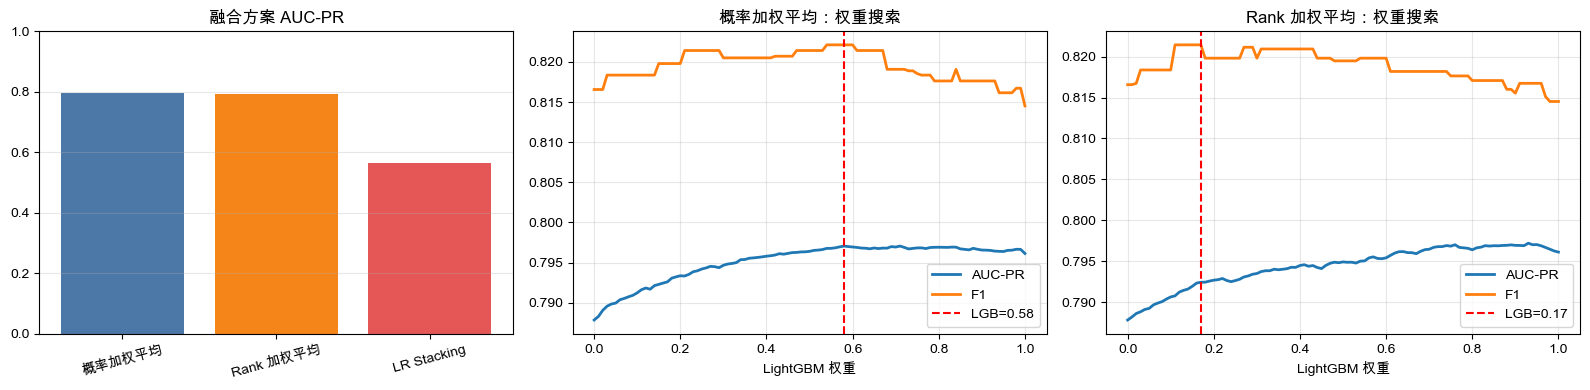

最优 Rank 加权权重: LGB=0.17, XGB=0.83


,meta_feature,coef_mean,coef_std
0,lgb_oof,0.00602,0.00411
1,xgb_oof,-0.00100,0.00140


In [21]:
# --- 4. 融合方案对比图 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_df = fusion_results.copy()
plot_df['label'] = plot_df['method'].map({
    'weighted_average_best': '概率加权平均',
    'rank_average_best': 'Rank 加权平均',
    'logistic_stacking': 'LR Stacking',
})
axes[0].bar(plot_df['label'], plot_df['AUC-PR'], color=['#4C78A8', '#F58518', '#E45756'])
axes[0].set_title('融合方案 AUC-PR')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(weighted_grid['w_lgb'], weighted_grid['AUC-PR'], label='AUC-PR', linewidth=2)
axes[1].plot(weighted_grid['w_lgb'], weighted_grid['F1'], label='F1', linewidth=2)
axes[1].axvline(best_weighted['w_lgb'], color='red', linestyle='--', label=f"LGB={best_weighted['w_lgb']:.2f}")
axes[1].set_title('概率加权平均：权重搜索')
axes[1].set_xlabel('LightGBM 权重')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(rank_grid['w_lgb'], rank_grid['AUC-PR'], label='AUC-PR', linewidth=2)
axes[2].plot(rank_grid['w_lgb'], rank_grid['F1'], label='F1', linewidth=2)
axes[2].axvline(best_rank['w_lgb'], color='red', linestyle='--', label=f"LGB={best_rank['w_lgb']:.2f}")
axes[2].set_title('Rank 加权平均：权重搜索')
axes[2].set_xlabel('LightGBM 权重')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('最优 Rank 加权权重: LGB={:.2f}, XGB={:.2f}'.format(best_rank['w_lgb'], best_rank['w_xgb']))
stack_coef_summary = stack_coef.groupby('meta_feature', as_index=False).agg(coef_mean=('coef', 'mean'), coef_std=('coef', 'std'))
display(stack_coef_summary.round(5))
